In [1]:
%matplotlib inline

import intake
from access_nri_intake.source.builders import AccessOm2Builder

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
import matplotlib.pyplot as pyplot

from netCDF4 import Dataset

import xesmf as xe

import warnings

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

# figdir = '/g/data/e14/pc5520/figures/basal_melt_param/'
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/8787/status'

In [2]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'


In [3]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl
).build()

builder.save(
    name="DSW_control", 
    description="An example datastore for ACCESS-OM2 ryf9091 DSW control",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control.json
CPU times: user 13.2 s, sys: 4.47 s, total: 17.6 s
Wall time: 40.4 s


In [4]:
%%time

builder = AccessOm2Builder(
    path=path_noBG
).build()

builder.save(
    name="Basal", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal.json
CPU times: user 8.22 s, sys: 5.45 s, total: 13.7 s
Wall time: 16.2 s


In [5]:
%%time

builder = AccessOm2Builder(
    path=path_BG
).build()

builder.save(
    name="Basal_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH.json
CPU times: user 4.15 s, sys: 2.55 s, total: 6.7 s
Wall time: 8.09 s


In [6]:
%%time

builder = AccessOm2Builder(
    path=path_BGB
).build()

builder.save(
    name="Basal_LH_Brine", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine.json
CPU times: user 5.07 s, sys: 3.29 s, total: 8.36 s
Wall time: 10.2 s


In [7]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable"] # This is important
)
# ds = cat.search(variable="temp").to_dask()

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BG = intake.open_esm_datastore(
    "./Basal_LH.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable"] # This is important
)

In [8]:
%%time
# Make sure these match the available restarts:
start_time='1907-01-01'
end_time='1909-12-31'
lat_slice  = slice(-80,-59)


CPU times: user 2 μs, sys: 6 μs, total: 8 μs
Wall time: 16.9 μs


In [19]:
d1 = cat.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_ctrl = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat.search(variable="river", frequency='1mon').to_dask()
river_ctrl = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_ctrl = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_ctrl = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_ctrl = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_ctrl = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat.search(variable="fprec", frequency='1mon').to_dask()
fprec_ctrl = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d10 = cat.search(variable="lprec", frequency='1mon').to_dask()
lprec_ctrl = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat.search(variable="evap", frequency='1mon').to_dask()
evap = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [20]:
d1 = cat_noBG.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_noBG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_noBG.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_noBG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_noBG.search(variable="river", frequency='1mon').to_dask()
river_noBG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_noBG.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_noBG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_noBG.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_noBG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_noBG.search(variable="basal_fwflx2d", frequency='1mon',file_id='rregionocean_monthly_2d_basal').to_dask()
basal2d_noBG = d6.sel(time=slice(start_time, end_time)).isel(yt_ocean_sub01=slice(27,-1))

d7 = cat_noBG.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_noBG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_noBG.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_noBG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_noBG.search(variable="icb_fwflx2d", frequency='1mon',file_id='rregionocean_monthly_2d_basal').to_dask()
icb2d_noBG = d9.sel(time=slice(start_time, end_time)).isel(yt_ocean_sub01=slice(27,-1))

In [11]:
# d6 = cat_noBG.search(variable="basal_fwflx2d", frequency='1mon').to_dask()
# cat_noBG.search(variable="basal_fwflx2d", frequency='1mon',file_id='rregionocean_monthly_2d_basal').keys() 

In [12]:
d1 = cat_BG.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_BG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BG.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_BG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BG.search(variable="river", frequency='1mon').to_dask()
river_BG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BG.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_BG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BG.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_BG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BG.search(variable="basal_fwflx2d", frequency='1mon').to_dask()
basal2d_BG = d6.sel(time=slice(start_time, end_time)).isel(yt_ocean_sub01=slice(27,-1))

d7 = cat_BG.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_BG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BG.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_BG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [26]:
d1 = cat_BGB.search(variable="pme_net", frequency='1mon').to_dask()
pme_net_BGB = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BGB.search(variable="pme_river", frequency='1mon').to_dask()
pme_river_BGB = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BGB.search(variable="river", frequency='1mon').to_dask()
river_BGB = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BGB.search(variable="wfimelt", frequency='1mon').to_dask()
wfimelt_BGB = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BGB.search(variable="wfiform", frequency='1mon').to_dask()
wfiform_BGB = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BGB.search(variable="basal_fwflx2d", frequency='1mon',file_id='ocean_monthly_2d_basal').to_dask()
basal2d_BGB = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_BGB.search(variable="sfc_salt_flux_ice", frequency='1mon').to_dask()
sfc_salt_flux_ice_BGB = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BGB.search(variable="sfc_salt_flux_restore", frequency='1mon').to_dask()
sfc_salt_flux_restore_BGB = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BGB.search(variable="briner_fwflx2d", frequency='1mon').to_dask()
brine_BGB = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

In [27]:
d1 = cat.search(variable="salt", frequency='1mon').to_dask()
SSS_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_noBG.search(variable="salt", frequency='1mon').to_dask()
SSS_noBG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_BG.search(variable="salt", frequency='1mon').to_dask()
SSS_BG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)
d1 = cat_BGB.search(variable="salt", frequency='1mon').to_dask()
SSS_BGB = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)


In [28]:
# convert salt fluxes to FW equivalent:

# A. Kiss don't think we should add this salt fluxes here; we're comparing them but the surface FW budget is given by:
# PME_RIVER = RIVER + MELT (wfiform+wfimelt) + PME (pme_net - (wfiform+wfimelt)) 
FW_restore_ctrl = -(sfc_salt_flux_restore_ctrl.to_dataarray().squeeze()*1000)/SSS_ctrl.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_BG = -(sfc_salt_flux_restore_BG.to_dataarray().squeeze()*1000)/SSS_BG.isel(st_ocean=0).to_dataarray().squeeze()
# FW_restore_ICB = -(sfc_salt_flux_restore_ICB.to_dataarray().squeeze()*1000)/SSS_ICB.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_noBG = -(sfc_salt_flux_restore_noBG.to_dataarray().squeeze()*1000)/SSS_noBG.isel(st_ocean=0).to_dataarray().squeeze()
FW_restore_BGB = -(sfc_salt_flux_restore_BGB.to_dataarray().squeeze()*1000)/SSS_BGB.isel(st_ocean=0).to_dataarray().squeeze()

# He also says we should use "the fixed bulk salinity of sea ice (ice_salt_concentration = 0.005 kg salt / kg ice), not SSS"
SSSi = 1/0.005

FW_ice_ctrl = -(sfc_salt_flux_ice_ctrl.to_dataarray().squeeze()*1000)/SSSi
FW_ice_BG = -(sfc_salt_flux_ice_BG.to_dataarray().squeeze()*1000)/SSSi
# FW_ice_ICB = -(sfc_salt_flux_ice_ICB.to_dataarray().squeeze()*1000)/SSSi
FW_ice_noBG = -(sfc_salt_flux_ice_noBG.to_dataarray().squeeze()*1000)/SSSi
FW_ice_BGB = -(sfc_salt_flux_ice_BGB.to_dataarray().squeeze()*1000)/SSSi


In [29]:
# rename dimensions in basal/icb to match other vars
basal2d_BG = basal2d_BG.rename({'xt_ocean_sub01': 'xt_ocean','yt_ocean_sub01': 'yt_ocean'})
# basal2d_ICB = basal2d_ICB.rename({'xt_ocean_sub01': 'xt_ocean','yt_ocean_sub01': 'yt_ocean'})
# icb2d_ICB = icb2d_ICB.rename({'xt_ocean_sub01': 'xt_ocean','yt_ocean_sub01': 'yt_ocean'})
basal2d_noBG = basal2d_noBG.rename({'xt_ocean_sub01': 'xt_ocean','yt_ocean_sub01': 'yt_ocean'})
icb2d_noBG =icb2d_noBG.rename({'xt_ocean_sub01': 'xt_ocean','yt_ocean_sub01': 'yt_ocean'})


In [30]:
d1 = cat.search(variable="area_t",path='/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d1.sel(yt_ocean=lat_slice)
area_t = oc_grd.area_t

d2 = cat.search(variable="ht",path='/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d2.sel(yt_ocean=lat_slice)
ht = oc_grd.ht

land_mask = np.squeeze(ht)*0
land_mask_fld = land_mask.fillna(1)
land_mask_fld = np.where(land_mask_fld==1,land_mask_fld,np.nan)
land_mask_masked = np.ma.masked_where((land_mask_fld==0),land_mask_fld)

# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

In [31]:
%%time
import numpy.ma as ma

# function to do annual avg and horiz. integral: ONLY SHELF
def var_tavg_hint_shelf(var2d):
    print(var2d.shape)
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht > 1000, var) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

# function to test difference b/w horz integral (above) and mean/std:
def var_tavg_havg_std_shelf(var2d): #
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht > 1000, var) # masked offshore 1000m isobath
    var_havg = np.nanmean(np.nanmean(var_masked, axis=1), axis=0) # sum along x/y axis
    var_hstd = np.nanstd(np.nanstd(var_masked, axis=1), axis=0) # sum along x/y axis

    return var_havg, var_hstd


# function to gave integrated on time but no annual average:
def var_hint_shelf(var2d):
    print(var2d.shape)
    # get time length:
    tlen = len(var2d.time)
    for ii in range(0,tlen):
        var_masked = ma.masked_where(ht > 1000, var2d.isel(time=ii)) # masked offshore 1000m isobath
        var_masked_area_tmp = var_masked*area_t # multiply by area
        if ii==0:
             var_hint = np.empty(tlen)
        var_hint_tmp = np.nansum(np.nansum(var_masked_area_tmp, axis=1), axis=0) # sum along x/y axis
        var_hint[ii] = var_hint_tmp
        del var_hint_tmp

    return var_hint

CPU times: user 52 μs, sys: 50 μs, total: 102 μs
Wall time: 122 μs


### calculate horiz.-integrated, annual average budget

In [32]:
%%time

pme_net_annual_hint_shelf_ctrl = var_tavg_hint_shelf(pme_net_ctrl.to_dataarray().squeeze())
pme_river_annual_hint_shelf_ctrl = var_tavg_hint_shelf(pme_river_ctrl.to_dataarray().squeeze())
river_annual_hint_shelf_ctrl = var_tavg_hint_shelf(river_ctrl.to_dataarray().squeeze())

# melt_annual_hint_shelf_ctrl = var_tavg_hint_shelf(melt_ctrl.to_dataarray().squeeze())
##melt_ctrl = wfiform_ctrl + wfimelt_ctrl
wfiform_annual_hint_shelf_ctrl = var_tavg_hint_shelf(wfiform_ctrl.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_ctrl = var_tavg_hint_shelf(wfimelt_ctrl.to_dataarray().squeeze())

FW_restore_annual_hint_shelf_ctrl = var_tavg_hint_shelf(FW_restore_ctrl)
FW_ice_annual_hint_shelf_ctrl = var_tavg_hint_shelf(FW_ice_ctrl)


(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 18 s, sys: 1.68 s, total: 19.7 s
Wall time: 21.5 s


In [33]:
# %%time

# pme_net_annual_havg_shelf_ctrl, pme_net_annual_hstd_shelf_ctrl = var_tavg_havg_std_shelf(pme_net.to_dataarray().squeeze())
# pme_river_annual_havg_shelf_ctrl, pme_river_annual_hstd_shelf_ctrl = var_tavg_havg_std_shelf(pme_river.to_dataarray().squeeze())
# river_annual_havg_shelf_ctrl, river_annual_hstd_shelf_ctrl = var_tavg_havg_std_shelf(river.to_dataarray().squeeze())
# melt_annual_havg_shelf_ctrl, melt_annual_hstd_shelf_ctrl = var_tavg_havg_std_shelf(melt.to_dataarray().squeeze())
# FW_restore_annual_havg_shelf_ctrl, FW_restore_annual_hstd_shelf_ctrl = var_tavg_havg_std_shelf(FW_restore_ctrl)
# FW_ice_annual_havg_shelf_ctrl, FW_ice_annual_hstd_shelf_ctrl = var_tavg_havg_std_shelf(FW_ice)


In [34]:
%%time

pme_net_annual_hint_shelf_BG = var_tavg_hint_shelf(pme_net_BG.to_dataarray().squeeze())
pme_river_annual_hint_shelf_BG = var_tavg_hint_shelf(pme_river_BG.to_dataarray().squeeze())
river_annual_hint_shelf_BG = var_tavg_hint_shelf(river_BG.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_BG = var_tavg_hint_shelf(wfimelt_BG.to_dataarray().squeeze())
wfiform_annual_hint_shelf_BG = var_tavg_hint_shelf(wfiform_BG.to_dataarray().squeeze())
FW_restore_annual_hint_shelf_BG = var_tavg_hint_shelf(FW_restore_BG)
FW_ice_annual_hint_shelf_BG = var_tavg_hint_shelf(FW_ice_BG)
basal_annual_hint_shelf_BG = var_tavg_hint_shelf(basal2d_BG.to_dataarray().squeeze())


(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 1min 34s, sys: 6.06 s, total: 1min 40s
Wall time: 1min 43s


In [35]:
# %%time

# pme_net_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_net_ICB.to_dataarray().squeeze())
# pme_river_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_river_ICB.to_dataarray().squeeze())
# river_annual_hint_shelf_ICB = var_tavg_hint_shelf(river_ICB.to_dataarray().squeeze())
# melt_annual_hint_shelf_ICB = var_tavg_hint_shelf(melt_ICB.to_dataarray().squeeze())
# FW_restore_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_restore_ICB)
# FW_ice_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_ice_ICB)

# basal_annual_hint_shelf_ICB = var_tavg_hint_shelf(basal2d_ICB.to_dataarray().squeeze())
# icb_annual_hint_shelf_ICB = var_tavg_hint_shelf(icb2d_ICB.to_dataarray().squeeze())

In [36]:
%%time

pme_net_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_net_noBG.to_dataarray().squeeze())
pme_river_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_river_noBG.to_dataarray().squeeze())
river_annual_hint_shelf_noBG = var_tavg_hint_shelf(river_noBG.to_dataarray().squeeze())

wfimelt_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfimelt_noBG.to_dataarray().squeeze())
wfiform_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfiform_noBG.to_dataarray().squeeze())
FW_ice_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_ice_noBG)
FW_restore_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_restore_noBG)

basal_annual_hint_shelf_noBG = var_tavg_hint_shelf(basal2d_noBG.to_dataarray().squeeze())
icb_annual_hint_shelf_noBG = var_tavg_hint_shelf(icb2d_noBG.to_dataarray().squeeze())

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 3min 1s, sys: 11.1 s, total: 3min 12s
Wall time: 3min 16s


In [37]:
%%time

pme_net_annual_hint_shelf_BGB = var_tavg_hint_shelf(pme_net_BGB.to_dataarray().squeeze())
pme_river_annual_hint_shelf_BGB = var_tavg_hint_shelf(pme_river_BGB.to_dataarray().squeeze())
river_annual_hint_shelf_BGB = var_tavg_hint_shelf(river_BGB.to_dataarray().squeeze())
wfimelt_annual_hint_shelf_BGB = var_tavg_hint_shelf(wfimelt_BGB.to_dataarray().squeeze())
wfiform_annual_hint_shelf_BGB = var_tavg_hint_shelf(wfiform_BGB.to_dataarray().squeeze())
FW_restore_annual_hint_shelf_BGB = var_tavg_hint_shelf(FW_restore_BGB)
FW_ice_annual_hint_shelf_BGB = var_tavg_hint_shelf(FW_ice_BGB)
basal_annual_hint_shelf_BGB = var_tavg_hint_shelf(basal2d_BGB.to_dataarray().squeeze())
brine_annual_hint_shelf_BGB = var_tavg_hint_shelf(brine_BGB.to_dataarray().squeeze())


(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 22 s, sys: 2.27 s, total: 24.3 s
Wall time: 27 s


In [38]:
# calculate melt = wfiform + wfimelt

melt_annual_hint_shelf_ctrl = wfiform_annual_hint_shelf_ctrl + wfimelt_annual_hint_shelf_ctrl
melt_annual_hint_shelf_noBG = wfiform_annual_hint_shelf_noBG + wfimelt_annual_hint_shelf_noBG
melt_annual_hint_shelf_BG = wfiform_annual_hint_shelf_BG + wfimelt_annual_hint_shelf_BG
melt_annual_hint_shelf_BGB = wfiform_annual_hint_shelf_BGB + wfimelt_annual_hint_shelf_BGB
# melt_annual_hint_shelf_ICB = wfiform_annual_hint_shelf_ICB + wfimelt_annual_hint_shelf_ICB


#### test with avg and std vs integral (horz):

In [26]:
area_masked = ma.masked_where(ht > 1000, area_t)

In [27]:
area_sum = np.nansum(np.nansum(area_masked, axis=1), axis=0)

In [28]:
# plot scatter of all values (before averaging):
# pme_net.shape
var = pme_net.mean('time') # annual mean
var_masked = ma.masked_where(ht > 1000, var)

print(var_masked.shape)
plt.plot(var_masked,',')


NameError: name 'pme_net' is not defined

In [ ]:
print(pme_net_annual_hint_shelf_ctrl, pme_net_annual_havg_shelf_ctrl*area_sum, pme_net_annual_hstd_shelf_ctrl*area_sum,
      pme_net_annual_havg_shelf_ctrl, (pme_net_annual_hstd_shelf_ctrl), area_sum)

In [ ]:
print(melt_annual_hint_shelf_ctrl, melt_annual_havg_shelf_ctrl*area_sum, melt_annual_hstd_shelf_ctrl*area_sum,
      melt_annual_havg_shelf_ctrl, (melt_annual_hstd_shelf_ctrl), area_sum)

In [ ]:
print(pme_river_annual_hint_shelf_ctrl, pme_river_annual_havg_shelf_ctrl*area_sum, pme_river_annual_hstd_shelf_ctrl*area_sum,
      pme_river_annual_havg_shelf_ctrl, (pme_river_annual_hstd_shelf_ctrl), area_sum)

In [ ]:
print(pme_river_annual_hint_shelf_ctrl, pme_river_annual_havg_shelf_ctrl*area_sum, pme_river_annual_hstd_shelf_ctrl*area_sum,
      pme_river_annual_havg_shelf_ctrl, (pme_river_annual_hstd_shelf_ctrl), area_sum)

In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,6))
# pme_river = pme_net + river
pyplot.bar(0, pme_river_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = pme_river_annual_havg_shelf_ctrl*area_sum
std = (+pme_river_annual_hstd_shelf_ctrl)*area_sum
ax.plot([-.3,.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([-.3,.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([-.3,.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)
plt.legend()

# pme_net - melt
pyplot.bar(1, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = (pme_net_annual_havg_shelf_ctrl-melt_annual_havg_shelf_ctrl)*area_sum
std = (+pme_net_annual_hstd_shelf_ctrl-melt_annual_hstd_shelf_ctrl)*area_sum
ax.plot([0.7,1.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([0.7,1.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([0.7,1.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# river
pyplot.bar(2, river_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = river_annual_havg_shelf_ctrl*area_sum
std = (+river_annual_hstd_shelf_ctrl)*area_sum
ax.plot([1.7,2.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([1.7,2.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([1.7,2.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# melt
pyplot.bar(3, melt_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = melt_annual_havg_shelf_ctrl*area_sum
std = (+melt_annual_hstd_shelf_ctrl)*area_sum
ax.plot([2.7,3.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([2.7,3.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([2.7,3.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# wfiform
pyplot.bar(4, wfiform_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = wfiform_annual_havg_shelf_ctrl*area_sum
std = (+wfiform_annual_hstd_shelf_ctrl)*area_sum
ax.plot([3.7,4.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([3.7,4.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([3.7,4.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# wfimelt
pyplot.bar(5, wfimelt_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = wfimelt_annual_havg_shelf_ctrl*area_sum
std = (+wfimelt_annual_hstd_shelf_ctrl)*area_sum
ax.plot([4.7,5.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([4.7,5.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([4.7,5.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# FW_restore
pyplot.bar(6, FW_restore_annual_hint_shelf_ctrl, width=0.25, color='k', label='Control')
mean = FW_restore_annual_havg_shelf_ctrl*area_sum
std = (+FW_restore_annual_hstd_shelf_ctrl)*area_sum
ax.plot([5.7,6.3], [mean, mean], color='red', linewidth=2, label=f'Mean')#: {mean:.2f}')
ax.plot([5.7,6.3], [mean + std, mean + std], color='green', linestyle='--', linewidth=1, label=f'Standard Deviation')#: {std:.2f}')
ax.plot([5.7,6.3], [mean - std, mean - std], color='green', linestyle='--', linewidth=1)

# ax.set_xticks(np.arange(0,8),('pme_river \n (net FWF)','pme_net \n - melt','river \n river+basal2d \n river+basal2d+icb','melt',
#                               'FW_ice','FW_restore','basal2d (Basal) \n basal2d+icb2d (ICB)','river \n (Basal/ICB)'),rotation=45)

ax.set_xticks(np.arange(0,8),('pme_river \n (net FWF)','pme_net \n - melt','river','melt','wfiform','wfimelt','FW_restore'),rotation=45)
ax.set_xlabel('SFWF components',fontsize=16)
ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=16)

plt.title('Freshwater budget south of 1500m')

### Save fig
# plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr10.png')


In [ ]:
#### 

In [ ]:
%%time

pme_net_annual_hint_shelf_BG = var_tavg_hint_shelf(pme_net_BG)
pme_river_annual_hint_shelf_BG = var_tavg_hint_shelf(pme_river_BG)
river_annual_hint_shelf_BG = var_tavg_hint_shelf(river_BG)
melt_annual_hint_shelf_BG = var_tavg_hint_shelf(melt_BG)
FW_restore_annual_hint_shelf_BG = var_tavg_hint_shelf(FW_restore_BG)
FW_ice_annual_hint_shelf_BG = var_tavg_hint_shelf(FW_ice_BG)
basal_annual_hint_shelf_BG = var_tavg_hint_shelf(basal2d_BG)


In [ ]:
%%time

pme_net_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_net_ICB)
pme_river_annual_hint_shelf_ICB = var_tavg_hint_shelf(pme_river_ICB)
river_annual_hint_shelf_ICB = var_tavg_hint_shelf(river_ICB)
melt_annual_hint_shelf_ICB = var_tavg_hint_shelf(melt_ICB)
FW_restore_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_restore_ICB)
FW_ice_annual_hint_shelf_ICB = var_tavg_hint_shelf(FW_ice_ICB)

basal_annual_hint_shelf_ICB = var_tavg_hint_shelf(basal2d_ICB)
icb_annual_hint_shelf_ICB = var_tavg_hint_shelf(icb2d_ICB)

In [ ]:
%%time

pme_net_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_net_noBG)
pme_river_annual_hint_shelf_noBG = var_tavg_hint_shelf(pme_river_noBG)
river_annual_hint_shelf_noBG = var_tavg_hint_shelf(river_noBG)
basal_annual_hint_shelf_noBG = var_tavg_hint_shelf(basal2d_noBG)
icb_annual_hint_shelf_noBG = var_tavg_hint_shelf(icb2d_noBG)
melt_annual_hint_shelf_noBG = var_tavg_hint_shelf(melt_noBG)
FW_ice_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_ice_noBG)
FW_restore_annual_hint_shelf_noBG = var_tavg_hint_shelf(FW_restore_noBG)


In [ ]:
%%time

pme_net_annual_hint_shelf_BGB = var_tavg_hint_shelf(pme_net_BGB)
pme_river_annual_hint_shelf_BGB = var_tavg_hint_shelf(pme_river_BGB)
river_annual_hint_shelf_BGB = var_tavg_hint_shelf(river_BGB)
melt_annual_hint_shelf_BGB = var_tavg_hint_shelf(melt_BGB)
FW_restore_annual_hint_shelf_BGB = var_tavg_hint_shelf(FW_restore_BGB)
FW_ice_annual_hint_shelf_BGB = var_tavg_hint_shelf(FW_ice_BGB)
basal_annual_hint_shelf_BGB = var_tavg_hint_shelf(basal2d_BGB)
brine_annual_hint_shelf_BGB = var_tavg_hint_shelf(brine_BGB)


In [ ]:
%%time
## do also for melt components: wfiform/wfimelt

wfimelt_annual_hint_shelf_ctrl = var_tavg_hint_shelf(wfimelt)
wfiform_annual_hint_shelf_ctrl = var_tavg_hint_shelf(wfiform)
wfimelt_annual_hint_shelf_BG = var_tavg_hint_shelf(wfimelt_BG)
wfiform_annual_hint_shelf_BG = var_tavg_hint_shelf(wfiform_BG)
wfimelt_annual_hint_shelf_ICB = var_tavg_hint_shelf(wfimelt_ICB)
wfiform_annual_hint_shelf_ICB = var_tavg_hint_shelf(wfiform_ICB)
wfimelt_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfimelt_noBG)
wfiform_annual_hint_shelf_noBG = var_tavg_hint_shelf(wfiform_noBG)
wfimelt_annual_hint_shelf_BGB = var_tavg_hint_shelf(wfimelt_BGB)
wfiform_annual_hint_shelf_BGB = var_tavg_hint_shelf(wfiform_BGB)


### final plots (annual avg):

In [39]:
# print values for a table:

print(' --- NET ---')
print('Control = ', pme_river_annual_hint_shelf_ctrl*1e-8)
print('BG = ', pme_river_annual_hint_shelf_BG*1e-8)
# print('ICB = ', pme_river_annual_hint_shelf_ICB*1e-8)
print('noBG = ', pme_river_annual_hint_shelf_noBG*1e-8)
print('BGB = ', pme_river_annual_hint_shelf_BGB*1e-8)

print(' --- PME ---')
print('Control = ', (pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl)*1e-8)
print('BG = ', (pme_net_annual_hint_shelf_BG - melt_annual_hint_shelf_BG)*1e-8)
# print('ICB = ', (pme_net_annual_hint_shelf_ICB - melt_annual_hint_shelf_ICB)*1e-8)
print('noBG = ', (pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG)*1e-8)
print('BGB = ', (pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB)*1e-8)

print(' --- RUNOFF (TOTAL) ---')
print('Control = ', river_annual_hint_shelf_ctrl*1e-8)
print('BG = ', (river_annual_hint_shelf_BG + basal_annual_hint_shelf_BG)*1e-8)
# print('ICB = ', (river_annual_hint_shelf_ICB + basal_annual_hint_shelf_ICB + icb_annual_hint_shelf_ICB)*1e-8)
print('noBG = ', (river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG)*1e-8)
print('BGB = ', (river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB)*1e-8)
print(' --- RUNOFF basal/icb only ---')
print('BG = ', basal_annual_hint_shelf_BG*1e-8)
# print('ICB = ', (basal_annual_hint_shelf_ICB + icb_annual_hint_shelf_ICB)*1e-8)
print('noBG = ', basal_annual_hint_shelf_noBG*1e-8)
print('BGb = ', basal_annual_hint_shelf_BGB*1e-8)

print(' --- SEA-ICE ---')
print('Control = ', melt_annual_hint_shelf_ctrl*1e-8)
print('BG = ', melt_annual_hint_shelf_BG*1e-8)
# print('ICB = ', melt_annual_hint_shelf_ICB*1e-8)
print('noBG = ', melt_annual_hint_shelf_noBG*1e-8)
print('BGB = ', melt_annual_hint_shelf_BGB*1e-8)

print(' --- SEA-ICE FORM. ---')
print('Control = ', wfiform_annual_hint_shelf_ctrl*1e-8)
print('BG = ', wfiform_annual_hint_shelf_BG*1e-8)
# print('ICB = ', wfiform_annual_hint_shelf_ICB*1e-8)
print('noBG = ', wfiform_annual_hint_shelf_noBG*1e-8)
print('BGB = ', wfiform_annual_hint_shelf_BGB*1e-8)

print(' --- SEA-ICE MELT ---')
print('Control = ', wfimelt_annual_hint_shelf_ctrl*1e-8)
print('BG = ', wfimelt_annual_hint_shelf_BG*1e-8)
# print('ICB = ', wfimelt_annual_hint_shelf_ICB*1e-8)
print('noBG = ', wfimelt_annual_hint_shelf_noBG*1e-8)
print('BGB = ', wfimelt_annual_hint_shelf_BGB*1e-8)

print(' --- FWF SEA-ICE ---')
print('Control = ', FW_ice_annual_hint_shelf_ctrl*1e-8)
print('BG = ', FW_ice_annual_hint_shelf_BG*1e-8)
# print('ICB = ', FW_ice_annual_hint_shelf_ICB*1e-8)
print('noBG = ', FW_ice_annual_hint_shelf_noBG*1e-8)
print('BGB = ', FW_ice_annual_hint_shelf_BGB*1e-8)

print(' --- FWF RESTORE ---')
print('Control = ', FW_restore_annual_hint_shelf_ctrl*1e-8)
print('BG = ', FW_restore_annual_hint_shelf_BG*1e-8)
# print('ICB = ', FW_restore_annual_hint_shelf_ICB*1e-8)
print('noBG = ', FW_restore_annual_hint_shelf_noBG*1e-8)
print('BGB = ', FW_restore_annual_hint_shelf_BGB*1e-8)


 --- NET ---
Control =  -1.09646216
BG =  -1.74847968
noBG =  -1.50331584
BGB =  1.534308
 --- PME ---
Control =  0.00505536
BG =  0.005884
noBG =  0.00366144
BGB =  3.2484
 --- RUNOFF (TOTAL) ---
Control =  0.8639032
BG =  0.8639032
noBG =  0.8639032
BGB =  0.8639032
 --- RUNOFF basal/icb only ---
BG =  0.45314952000000003
noBG =  0.45314952000000003
BGb =  0.45314952000000003
 --- SEA-ICE ---
Control =  -1.9654208
BG =  -2.16511744
noBG =  -1.9177308800000001
BGB =  -2.12484592
 --- SEA-ICE FORM. ---
Control =  -2.90630912
BG =  -3.38206784
noBG =  -2.8452176000000002
BGB =  -3.23947904
 --- SEA-ICE MELT ---
Control =  0.94088824
BG =  1.21695032
noBG =  0.9274868000000001
BGB =  1.11463312
 --- FWF SEA-ICE ---
Control =  0.05396028
BG =  0.059056040000000004
noBG =  0.05282091
BGB =  0.058025175
 --- FWF RESTORE ---
Control =  -0.0412274525
BG =  -0.0006719125
noBG =  -0.015856825
BGB =  -0.0201183525


In [40]:
# # plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
# fig, ax  = plt.subplots(figsize = (6,6))
# # pme_river = pme_net + river +basal2d+icb2d
# pyplot.bar(-.2,  pme_river_annual_hint_shelf_ctrl, width=0.2, color='k', label='Control')
# pyplot.bar(0.2,  pme_river_annual_hint_shelf_BG+ basal_annual_hint_shelf_BG, width=0.2, color='#BB5566', label='BasalGade')
# pyplot.bar(0.4, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue', label='BasalGadeBrine')
# pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.2, color='#DDAA33', label='Basal')

# # plt.legend(fontsize=20)

# # test with pme_net - melt
# pyplot.bar(0.8, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.2, color='k')
# pyplot.bar(1.2,  pme_net_annual_hint_shelf_BG - melt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
# pyplot.bar(1.4, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')
# pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# pyplot.bar(1.8, river_annual_hint_shelf_ctrl, width=0.2, color='k')
# pyplot.bar(2.2,  river_annual_hint_shelf_BG + basal_annual_hint_shelf_BG, width=0.2, color='#BB5566')
# pyplot.bar(2.4, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.2, color='steelblue')
# pyplot.bar(2., river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# # pme_net includes melt!
# pyplot.bar(2.8, melt_annual_hint_shelf_ctrl, width=0.2, color='k')
# pyplot.bar(3.2,  melt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
# pyplot.bar(3.4, melt_annual_hint_shelf_BGB, width=0.2, color='steelblue')
# pyplot.bar(3., melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# pyplot.bar(3.8, wfiform_annual_hint_shelf_ctrl, width=0.2, color='k')
# pyplot.bar(4.2,  wfiform_annual_hint_shelf_BG, width=0.2, color='#BB5566')
# pyplot.bar(4.4, wfiform_annual_hint_shelf_BGB, width=0.2, color='steelblue')
# pyplot.bar(4., wfiform_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# pyplot.bar(4.8, wfimelt_annual_hint_shelf_ctrl, width=0.2, color='k')
# pyplot.bar(5.2,  wfimelt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
# pyplot.bar(5.4, wfimelt_annual_hint_shelf_BGB, width=0.2, color='steelblue')
# pyplot.bar(5., wfimelt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# pyplot.bar(5.8, FW_restore_annual_hint_shelf_ctrl, width=0.2, color='k')
# pyplot.bar(6.2,  FW_restore_annual_hint_shelf_BG, width=0.2, color='#BB5566')
# pyplot.bar(6.4, FW_restore_annual_hint_shelf_BGB, width=0.2, color='steelblue')
# pyplot.bar(6., FW_restore_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')

# # pyplot.bar(7.4, brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')

# ax.set_xticks(np.arange(0,7),('Net FWF','PME','Runoff','SI net \n = ','(SI form. \n +','SI melt)',
#                               'SSS rest.'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

# ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=20)
# ax.set_ylim(-3.5e8,3.5e8)
# ax.yaxis.grid(True, linestyle=':')

# ax.set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=20)


# plt.title('Freshwater fluxes \n integrated over the continental shelf',fontsize=20)

# ### Save fig
# plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr8-10.png',bbox_inches='tight',dpi=300)


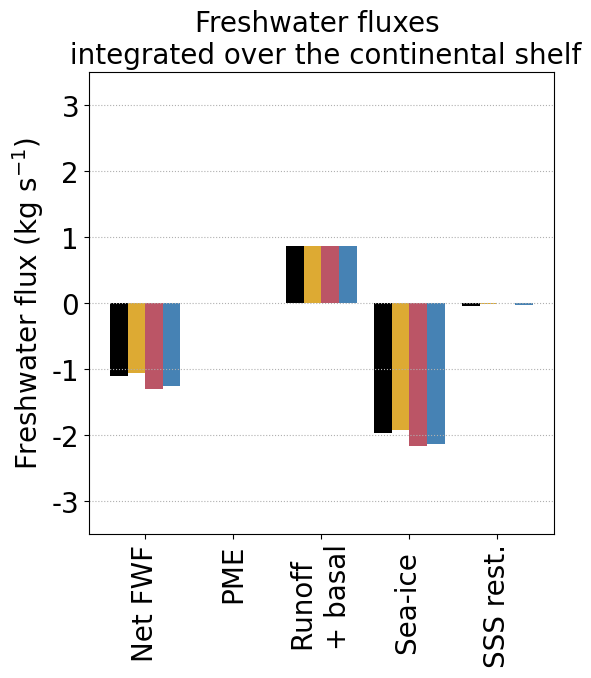

In [41]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (6,6))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.3,  pme_river_annual_hint_shelf_ctrl, width=0.2, color='k', label='Control')
pyplot.bar(-.1, pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.2, color='#DDAA33', label='Basal')
pyplot.bar(0.1,  pme_river_annual_hint_shelf_BG+ basal_annual_hint_shelf_BG, width=0.2, color='#BB5566', label='BasalGade')
pyplot.bar(0.3, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue', label='BasalGadeBrine')

# plt.legend(fontsize=20)

# test with pme_net - melt
pyplot.bar(0.7, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(.9, pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
pyplot.bar(1.1,  pme_net_annual_hint_shelf_BG - melt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
pyplot.bar(1.3, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')

pyplot.bar(1.7, river_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(1.9, river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
pyplot.bar(2.1,  river_annual_hint_shelf_BG + basal_annual_hint_shelf_BG, width=0.2, color='#BB5566')
pyplot.bar(2.3, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.2, color='steelblue')

# pme_net includes melt!
pyplot.bar(2.7, melt_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(2.9, melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
pyplot.bar(3.1,  melt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
pyplot.bar(3.3, melt_annual_hint_shelf_BGB, width=0.2, color='steelblue')

pyplot.bar(3.7, FW_restore_annual_hint_shelf_ctrl, width=0.2, color='k')
pyplot.bar(3.9, FW_restore_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
pyplot.bar(4.1,  FW_restore_annual_hint_shelf_BG, width=0.2, color='#BB5566')
pyplot.bar(4.3, FW_restore_annual_hint_shelf_BGB, width=0.2, color='steelblue')

# pyplot.bar(7.4, brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')

ax.set_xticks(np.arange(0,5),('Net FWF','PME','Runoff \n + basal','Sea-ice ',
                              'SSS rest.'),rotation=90,fontsize=20) #,'Brine'),rotation=45)

ax.set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=20)
ax.set_ylim(-3.5e8,3.5e8)
ax.yaxis.grid(True, linestyle=':')

ax.set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=20)


plt.title('Freshwater fluxes \n integrated over the continental shelf',fontsize=20)

### Save fig
plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr7-9.png',bbox_inches='tight',dpi=300)


In [42]:
print(figdir+'SFWF_components_annual_hint_shelf_yr8-10.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/SFWF_components_annual_hint_shelf_yr8-10.png


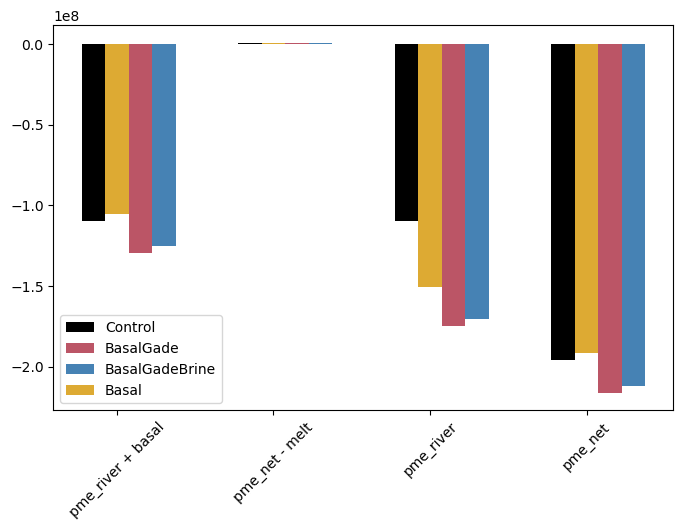

In [43]:
fig, ax  = plt.subplots(figsize = (8,5))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.15, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k', label='Control')
pyplot.bar(0.15, pme_river_annual_hint_shelf_BG+ basal_annual_hint_shelf_BG, width=0.15, color='#BB5566', label='BasalGade')
pyplot.bar(0.3, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33', label='Basal')
plt.legend()

# test with pme_net - melt
pyplot.bar(0.85, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(1.15, pme_net_annual_hint_shelf_BG - melt_annual_hint_shelf_BG, width=0.15, color='#BB5566')
pyplot.bar(1.3, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

pyplot.bar(1.85, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k')#, label='Control')
pyplot.bar(2.15, pme_river_annual_hint_shelf_BG , width=0.15, color='#BB5566')#, label='BasalGade')
pyplot.bar(2.3, pme_river_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')#, label='BasalGadeBrine')
pyplot.bar(2., pme_river_annual_hint_shelf_noBG , width=0.15, color='#DDAA33')#, label='Basal')

# test with pme_net - melt
pyplot.bar(2.85, pme_net_annual_hint_shelf_ctrl , width=0.15, color='k')
pyplot.bar(3.15, pme_net_annual_hint_shelf_BG , width=0.15, color='#BB5566')
pyplot.bar(3.3, pme_net_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB , width=0.15, color='steelblue')
pyplot.bar(3., pme_net_annual_hint_shelf_noBG , width=0.15, color='#DDAA33')

ax.set_xticks(np.arange(0,4),('pme_river + basal','pme_net - melt','pme_river','pme_net'),rotation=45)

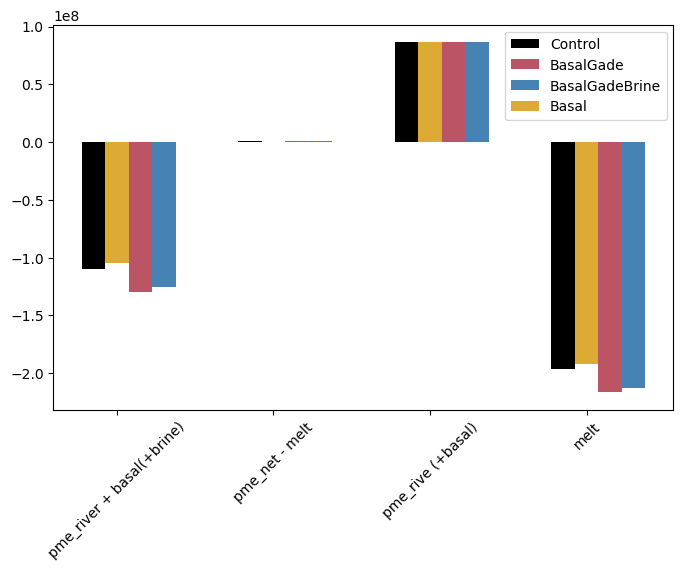

In [44]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (8,5))
# pme_river = pme_net + river +basal2d+icb2d
pyplot.bar(-.15, pme_river_annual_hint_shelf_ctrl, width=0.15, color='k', label='Control')
pyplot.bar(0.15, pme_river_annual_hint_shelf_BG+ basal_annual_hint_shelf_BG, width=0.15, color='#BB5566', label='BasalGade')
pyplot.bar(0.3, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue', label='BasalGadeBrine')
pyplot.bar(0., pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33', label='Basal')
plt.legend()

# test with pme_net - melt
pyplot.bar(0.85, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(1.15, pme_net_annual_hint_shelf_BG - melt_annual_hint_shelf_BG, width=0.15, color='#BB5566')
pyplot.bar(1.3, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(1., pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

pyplot.bar(1.85, river_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(2.15, river_annual_hint_shelf_BG + basal_annual_hint_shelf_BG, width=0.15, color='#BB5566')
pyplot.bar(2.3, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(2., river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

# pme_net includes melt!
pyplot.bar(2.85, melt_annual_hint_shelf_ctrl, width=0.15, color='k')
pyplot.bar(3.15, melt_annual_hint_shelf_BG, width=0.15, color='#BB5566')
pyplot.bar(3.3, melt_annual_hint_shelf_BGB, width=0.15, color='steelblue')
pyplot.bar(3., melt_annual_hint_shelf_noBG, width=0.15, color='#DDAA33')

ax.set_xticks(np.arange(0,4),('pme_river + basal(+brine)','pme_net - melt','pme_rive (+basal)','melt'),rotation=45)

### Plotting timeseries:

In [45]:
%%time

### -- all expts, timeseries (should take a long time):

pme_net_hint_shelf_ctrl = var_hint_shelf(pme_net_ctrl.to_dataarray().squeeze())
pme_river_hint_shelf_ctrl = var_hint_shelf(pme_river_ctrl.to_dataarray().squeeze())
river_hint_shelf_ctrl = var_hint_shelf(river_ctrl.to_dataarray().squeeze());
wfiform_hint_shelf_ctrl = var_hint_shelf(wfiform_ctrl.to_dataarray().squeeze())
wfimelt_hint_shelf_ctrl = var_hint_shelf(wfimelt_ctrl.to_dataarray().squeeze())
FW_restore_hint_shelf_ctrl = var_hint_shelf(FW_restore_ctrl)
FW_ice_hint_shelf_ctrl = var_hint_shelf(FW_ice_ctrl)

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 2min 59s, sys: 23.6 s, total: 3min 22s
Wall time: 4min 13s


In [46]:
%%time

pme_net_hint_shelf_BG = var_hint_shelf(pme_net_BG.to_dataarray().squeeze())
pme_river_hint_shelf_BG = var_hint_shelf(pme_river_BG.to_dataarray().squeeze())
river_hint_shelf_BG = var_hint_shelf(river_BG.to_dataarray().squeeze())
wfimelt_hint_shelf_BG = var_hint_shelf(wfimelt_BG.to_dataarray().squeeze())
wfiform_hint_shelf_BG = var_hint_shelf(wfiform_BG.to_dataarray().squeeze())
FW_restore_hint_shelf_BG = var_hint_shelf(FW_restore_BG)
FW_ice_hint_shelf_BG = var_hint_shelf(FW_ice_BG)
basal_hint_shelf_BG = var_hint_shelf(basal2d_BG.to_dataarray().squeeze())

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 10min 7s, sys: 41.8 s, total: 10min 48s
Wall time: 12min 35s


In [47]:
%%time

pme_net_hint_shelf_noBG = var_hint_shelf(pme_net_noBG.to_dataarray().squeeze())
pme_river_hint_shelf_noBG = var_hint_shelf(pme_river_noBG.to_dataarray().squeeze())
river_hint_shelf_noBG = var_hint_shelf(river_noBG.to_dataarray().squeeze())
wfimelt_hint_shelf_noBG = var_hint_shelf(wfimelt_noBG.to_dataarray().squeeze())
wfiform_hint_shelf_noBG = var_hint_shelf(wfiform_noBG.to_dataarray().squeeze())
FW_restore_hint_shelf_noBG = var_hint_shelf(FW_restore_noBG)
FW_ice_hint_shelf_noBG = var_hint_shelf(FW_ice_noBG)
basal_hint_shelf_noBG = var_hint_shelf(basal2d_noBG.to_dataarray().squeeze())


(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 21min 34s, sys: 1min 4s, total: 22min 38s
Wall time: 25min 7s


In [48]:
%%time

pme_net_hint_shelf_BGB = var_hint_shelf(pme_net_BGB.to_dataarray().squeeze())
pme_river_hint_shelf_BGB = var_hint_shelf(pme_river_BGB.to_dataarray().squeeze())
river_hint_shelf_BGB = var_hint_shelf(river_BGB.to_dataarray().squeeze())
wfimelt_hint_shelf_BGB = var_hint_shelf(wfimelt_BGB.to_dataarray().squeeze())
wfiform_hint_shelf_BGB = var_hint_shelf(wfiform_BGB.to_dataarray().squeeze())
FW_restore_hint_shelf_BGB = var_hint_shelf(FW_restore_BGB)
FW_ice_hint_shelf_BGB = var_hint_shelf(FW_ice_BGB)
basal_hint_shelf_BGB = var_hint_shelf(basal2d_BGB.to_dataarray().squeeze())

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 4min 56s, sys: 40.7 s, total: 5min 37s
Wall time: 8min 52s


In [49]:
%%time

brine_hint_shelf_BGB = var_hint_shelf(brine_BGB.to_dataarray().squeeze())

melt_ctrl = wfiform_ctrl.to_dataarray().squeeze() + wfimelt_ctrl.to_dataarray().squeeze()
melt_hint_shelf_ctrl = var_hint_shelf(melt_ctrl)

melt_noBG = wfiform_noBG.to_dataarray().squeeze() + wfimelt_noBG.to_dataarray().squeeze()
melt_hint_shelf_noBG = var_hint_shelf(melt_noBG)

melt_BG = wfiform_BG.to_dataarray().squeeze() + wfimelt_BG.to_dataarray().squeeze()
melt_hint_shelf_BG = var_hint_shelf(melt_BG)

melt_BGB = wfiform_BGB.to_dataarray().squeeze() + wfimelt_BGB.to_dataarray().squeeze()
melt_hint_shelf_BGB = var_hint_shelf(melt_BGB)

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 2min 52s, sys: 28 s, total: 3min 20s
Wall time: 6min 14s


(-600000000.0, 600000000.0)

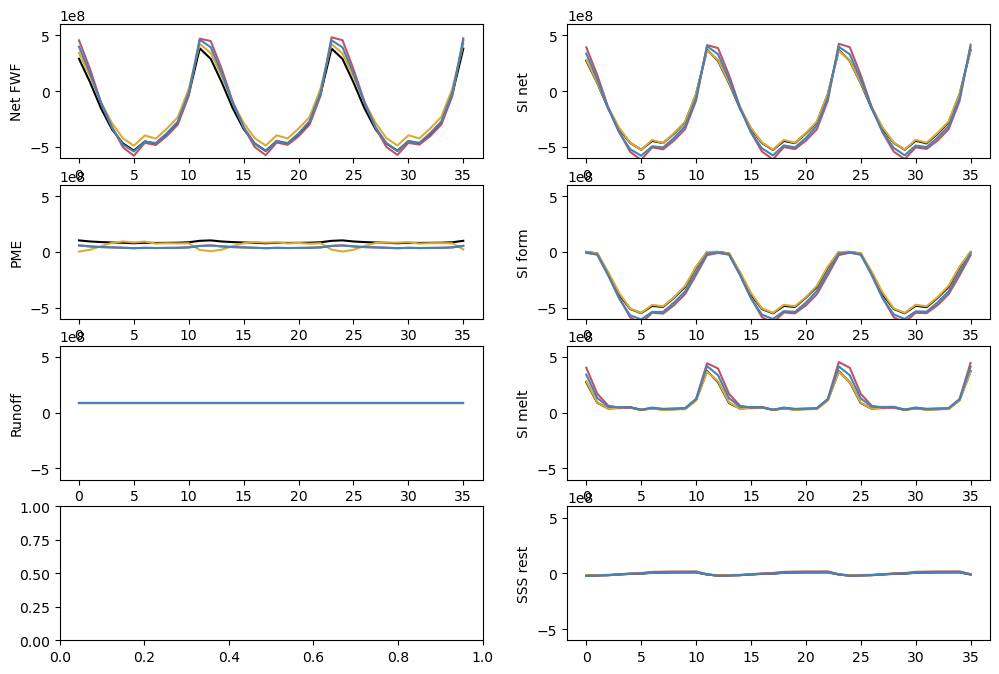

In [50]:
## test plotting timeseries:

fig, ax  = plt.subplots(nrows=4,ncols=2, figsize = (12,8))
ax[0,0].plot(pme_net_hint_shelf_ctrl,label='ctrl',color='k')
ax[0,0].plot(pme_net_hint_shelf_noBG + basal_hint_shelf_BGB,label='Basal',color='#DDAA33')
ax[0,0].plot(pme_net_hint_shelf_BG + basal_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[0,0].plot(pme_net_hint_shelf_BGB + basal_hint_shelf_BGB + brine_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[0,0].set_ylabel('Net FWF')
# ax[0].title('Net FWF',loc='outside')
ax[0,0].set_ylim(-6e8,+6e8)

# ax[1,0].plot((pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl),label='ctrl',color='k')
ax[1,0].plot(pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl,label='ctrl',color='k')
ax[1,0].plot(pme_river_hint_shelf_noBG - melt_hint_shelf_BGB,label='Basal',color='#DDAA33')
ax[1,0].plot(pme_river_hint_shelf_BG - melt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[1,0].plot(pme_river_hint_shelf_BGB - melt_hint_shelf_BGB + brine_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[1,0].set_ylabel('PME')
ax[1,0].set_ylim(-6e8,+6e8)

ax[2,0].plot(river_hint_shelf_ctrl,label='ctrl',color='k')
ax[2,0].plot(river_hint_shelf_noBG + basal_hint_shelf_BGB,label='Basal',color='#DDAA33')
ax[2,0].plot(river_hint_shelf_BG[0:118] + basal_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[2,0].plot(river_hint_shelf_BGB + basal_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[2,0].set_ylabel('Runoff')
ax[2,0].set_ylim(-6e8,+6e8)

ax[0,1].plot(melt_hint_shelf_ctrl,label='ctrl',color='k')
ax[0,1].plot(melt_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[0,1].plot(melt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[0,1].plot(melt_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[0,1].set_ylabel('SI net')
ax[0,1].set_ylim(-6e8,+6e8)

ax[1,1].plot(wfiform_hint_shelf_ctrl,label='ctrl',color='k')
ax[1,1].plot(wfiform_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[1,1].plot(wfiform_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[1,1].plot(wfiform_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[1,1].set_ylabel('SI form')
ax[1,1].set_ylim(-6e8,+6e8)

ax[2,1].plot(wfimelt_hint_shelf_ctrl,label='ctrl',color='k')
ax[2,1].plot(wfimelt_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[2,1].plot(wfimelt_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[2,1].plot(wfimelt_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[2,1].set_ylabel('SI melt')
ax[2,1].set_ylim(-6e8,+6e8)

ax[3,1].plot(FW_restore_hint_shelf_ctrl,label='ctrl',color='k')
ax[3,1].plot(FW_restore_hint_shelf_noBG,label='Basal',color='#DDAA33')
ax[3,1].plot(FW_restore_hint_shelf_BG,label='Basal_LH', color='#BB5566')
ax[3,1].plot(FW_restore_hint_shelf_BGB,label='Basal_LH_Brine', color='steelblue')
ax[3,1].set_ylabel('SSS rest')
ax[3,1].set_ylim(-6e8,+6e8)






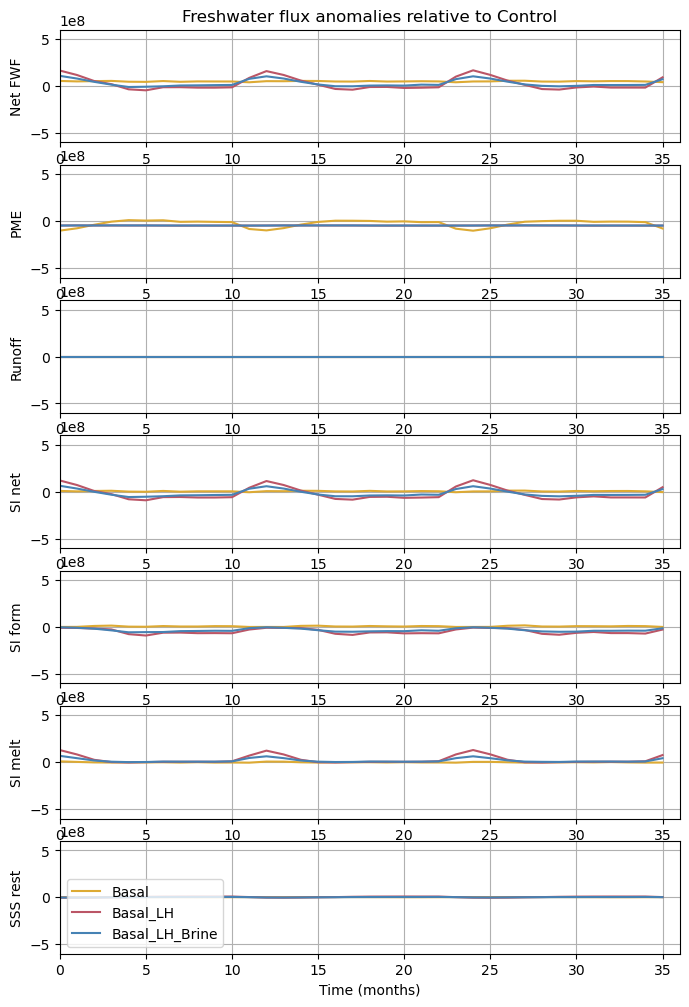

In [51]:
## test plotting timeseries:

fig, ax  = plt.subplots(nrows=7, figsize = (8,12))

ax[0].set_title('Freshwater flux anomalies relative to Control')

# ax[0].plot(pme_net_hint_shelf_ctrl,label='ctrl',color='k')
ax[0].plot(pme_net_hint_shelf_noBG + basal_hint_shelf_BGB - pme_net_hint_shelf_ctrl,label='Basal',color='#DDAA33')
ax[0].plot(pme_net_hint_shelf_BG + basal_hint_shelf_BG - pme_net_hint_shelf_ctrl[-37:],label='Basal_LH', color='#BB5566')
ax[0].plot(pme_net_hint_shelf_BGB + basal_hint_shelf_BGB + brine_hint_shelf_BGB - pme_net_hint_shelf_ctrl,label='Basal_LH_Brine', color='steelblue')
ax[0].set_ylabel('Net FWF')
# ax[0].title('Net FWF',loc='outside')
ax[0].set_ylim(-6e8,+6e8)

# ax[1].plot((pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl),label='ctrl',color='k')
# ax[1].plot(pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl,label='ctrl',color='k')
ctrl_pme=pme_river_hint_shelf_ctrl - melt_hint_shelf_ctrl
ax[1].plot(pme_river_hint_shelf_noBG - melt_hint_shelf_BGB -ctrl_pme,label='Basal',color='#DDAA33')
ax[1].plot(pme_river_hint_shelf_BG - melt_hint_shelf_BG -ctrl_pme[-37:],label='Basal_LH', color='#BB5566')
ax[1].plot(pme_river_hint_shelf_BGB - melt_hint_shelf_BGB + brine_hint_shelf_BGB -ctrl_pme,label='Basal_LH_Brine', color='steelblue')
ax[1].set_ylabel('PME')
ax[1].set_ylim(-6e8,+6e8)

# ax[2].plot(river_hint_shelf_ctrl,label='ctrl',color='k')
ax[2].plot(river_hint_shelf_noBG + basal_hint_shelf_BGB - river_hint_shelf_ctrl,label='Basal',color='#DDAA33')
ax[2].plot(river_hint_shelf_BG[0:118] + basal_hint_shelf_BG - river_hint_shelf_ctrl[-37:],label='Basal_LH', color='#BB5566')
ax[2].plot(river_hint_shelf_BGB + basal_hint_shelf_BGB - river_hint_shelf_ctrl,label='Basal_LH_Brine', color='steelblue')
ax[2].set_ylabel('Runoff')
ax[2].set_ylim(-6e8,+6e8)

# ax[0].plot(melt_hint_shelf_ctrl,label='ctrl',color='k')
ax[3].plot(melt_hint_shelf_noBG - melt_hint_shelf_ctrl,label='Basal',color='#DDAA33')
ax[3].plot(melt_hint_shelf_BG - melt_hint_shelf_ctrl[-37:],label='Basal_LH', color='#BB5566')
ax[3].plot(melt_hint_shelf_BGB - melt_hint_shelf_ctrl,label='Basal_LH_Brine', color='steelblue')
ax[3].set_ylabel('SI net')
ax[3].set_ylim(-6e8,+6e8)

# ax[1].plot(wfiform_hint_shelf_ctrl,label='ctrl',color='k')
ax[4].plot(wfiform_hint_shelf_noBG - wfiform_hint_shelf_ctrl,label='Basal',color='#DDAA33')
ax[4].plot(wfiform_hint_shelf_BG - wfiform_hint_shelf_ctrl[-37:],label='Basal_LH', color='#BB5566')
ax[4].plot(wfiform_hint_shelf_BGB - wfiform_hint_shelf_ctrl,label='Basal_LH_Brine', color='steelblue')
ax[4].set_ylabel('SI form')
ax[4].set_ylim(-6e8,+6e8)

# ax[2].plot(wfimelt_hint_shelf_ctrl,label='ctrl',color='k')
ax[5].plot(wfimelt_hint_shelf_noBG - wfimelt_hint_shelf_ctrl,label='Basal',color='#DDAA33')
ax[5].plot(wfimelt_hint_shelf_BG - wfimelt_hint_shelf_ctrl[-37:],label='Basal_LH', color='#BB5566')
ax[5].plot(wfimelt_hint_shelf_BGB - wfimelt_hint_shelf_ctrl,label='Basal_LH_Brine', color='steelblue')
ax[5].set_ylabel('SI melt')
ax[5].set_ylim(-6e8,+6e8)

# ax[3].plot(FW_restore_hint_shelf_ctrl,label='ctrl',color='k')
ax[6].plot(FW_restore_hint_shelf_noBG - FW_restore_hint_shelf_ctrl,label='Basal',color='#DDAA33')
ax[6].plot(FW_restore_hint_shelf_BG - FW_restore_hint_shelf_ctrl[-37:],label='Basal_LH', color='#BB5566')
ax[6].plot(FW_restore_hint_shelf_BGB - FW_restore_hint_shelf_ctrl,label='Basal_LH_Brine', color='steelblue')
ax[6].set_ylabel('SSS rest')
ax[6].set_ylim(-6e8,+6e8)
ax[6].set_xlabel('Time (months)')
ax[6].legend(loc='lower left')

for aa in range(0,7):
    ax[aa].grid('on')
    ax[aa].set_xlim([0,36])

plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr7-9_seasonal.png',bbox_inches='tight',dpi=300)




In [52]:
## calculate daily climatology:

def calculate_daily_clim(var):

    var_clim = np.empty((12))

    for ii in np.arange(0,12):
        tmp = var[ii] + var[ii+12] + var[ii+24]
        var_clim[ii] = np.divide(tmp,3)
        
    return var_clim


In [53]:
pme_river_hint_shelf_ctrl_clim = calculate_daily_clim(pme_river_hint_shelf_ctrl)
pme_river_hint_shelf_noBG_clim = calculate_daily_clim(pme_river_hint_shelf_noBG)
pme_river_hint_shelf_BG_clim = calculate_daily_clim(pme_river_hint_shelf_BG)
pme_river_hint_shelf_BGB_clim = calculate_daily_clim(pme_river_hint_shelf_BGB)

In [54]:
pme_net_hint_shelf_ctrl_clim = calculate_daily_clim(pme_net_hint_shelf_ctrl)
pme_net_hint_shelf_noBG_clim = calculate_daily_clim(pme_net_hint_shelf_noBG)
pme_net_hint_shelf_BG_clim = calculate_daily_clim(pme_net_hint_shelf_BG)
pme_net_hint_shelf_BGB_clim = calculate_daily_clim(pme_net_hint_shelf_BGB)

In [55]:
melt_hint_shelf_ctrl_clim = calculate_daily_clim(melt_hint_shelf_ctrl)
melt_hint_shelf_noBG_clim = calculate_daily_clim(melt_hint_shelf_noBG)
melt_hint_shelf_BG_clim = calculate_daily_clim(melt_hint_shelf_BG)
melt_hint_shelf_BGB_clim = calculate_daily_clim(melt_hint_shelf_BGB)

In [56]:
river_hint_shelf_ctrl_clim = calculate_daily_clim(river_hint_shelf_ctrl)
river_hint_shelf_noBG_clim = calculate_daily_clim(river_hint_shelf_noBG)
river_hint_shelf_BG_clim = calculate_daily_clim(river_hint_shelf_BG)
river_hint_shelf_BGB_clim = calculate_daily_clim(river_hint_shelf_BGB)

In [57]:
basal_hint_shelf_noBG_clim = calculate_daily_clim(basal_hint_shelf_noBG)
basal_hint_shelf_BG_clim = calculate_daily_clim(basal_hint_shelf_BG)
basal_hint_shelf_BGB_clim = calculate_daily_clim(basal_hint_shelf_BGB)

In [58]:
brine_hint_shelf_BGB_clim = calculate_daily_clim(brine_hint_shelf_BGB)

In [59]:
FW_restore_hint_shelf_ctrl_clim = calculate_daily_clim(FW_restore_hint_shelf_ctrl)
FW_restore_hint_shelf_noBG_clim = calculate_daily_clim(FW_restore_hint_shelf_noBG)
FW_restore_hint_shelf_BG_clim = calculate_daily_clim(FW_restore_hint_shelf_BG)
FW_restore_hint_shelf_BGB_clim = calculate_daily_clim(FW_restore_hint_shelf_BGB)

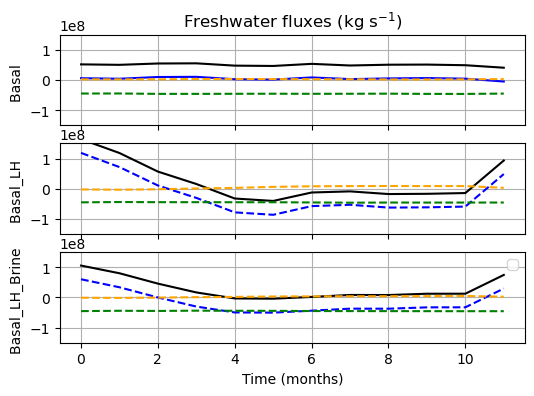

In [60]:
fig, ax  = plt.subplots(nrows=3,ncols=1, figsize = (6,4))
ax[0].set_title('Freshwater fluxes (kg s$^{-1}$)')
ax[0].plot(pme_net_hint_shelf_noBG_clim-pme_net_hint_shelf_ctrl_clim
         +basal_hint_shelf_noBG_clim
         ,label='Net',color='k')
ax[0].plot(melt_hint_shelf_noBG_clim-melt_hint_shelf_ctrl_clim
         ,'-',label='Sea ice',color='b')
ax[0].plot(pme_river_hint_shelf_noBG_clim-melt_hint_shelf_noBG_clim-
          (pme_river_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)
          ,'--',label='PME',color='g')
ax[0].plot(FW_restore_hint_shelf_noBG_clim-FW_restore_hint_shelf_ctrl_clim
          ,'--',label='SSS restoring',color='orange')
plt.legend(loc='best')

ax[1].plot(pme_net_hint_shelf_BG_clim-pme_net_hint_shelf_ctrl_clim
         +basal_hint_shelf_BG_clim
         ,label='Net', color='k')
ax[1].plot(melt_hint_shelf_BG_clim-melt_hint_shelf_ctrl_clim
         ,'--',label='Sea-ice', color='b')
ax[1].plot(pme_river_hint_shelf_BG_clim-melt_hint_shelf_BG_clim-
          (pme_river_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)
          ,'--',label='PME', color='g')
ax[1].plot(FW_restore_hint_shelf_BG_clim-FW_restore_hint_shelf_ctrl_clim
          ,'--',label='SSS restoring',color='orange')

ax[2].plot(pme_net_hint_shelf_BGB_clim-pme_net_hint_shelf_ctrl_clim
         +basal_hint_shelf_BGB_clim
         +brine_hint_shelf_BGB_clim
         ,label='Net', color='k')
ax[2].plot(melt_hint_shelf_BGB_clim-melt_hint_shelf_ctrl_clim
         ,'--',label='Sea ice', color='b')
ax[2].plot(pme_river_hint_shelf_BGB_clim-melt_hint_shelf_BGB_clim
           +brine_hint_shelf_BGB_clim-(pme_river_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)
          ,'--',label='PME', color='g')
ax[2].plot(FW_restore_hint_shelf_BGB_clim-FW_restore_hint_shelf_ctrl_clim
          ,'--',label='SSS restoring',color='orange')
ax[2].set_xlabel('Time (months)')
ax[0].set_xticklabels('')
ax[1].set_xticklabels('')


ax[0].set_ylim(-1.5e8,+1.5e8)
ax[1].set_ylim(-1.5e8,+1.5e8)
ax[2].set_ylim(-1.5e8,+1.5e8)
ax[0].set_ylabel('Basal ')           
ax[1].set_ylabel('Basal_LH ')           
ax[2].set_ylabel('Basal_LH_Brine ')     
ax[0].grid('on')
ax[1].grid('on')
ax[2].grid('on')

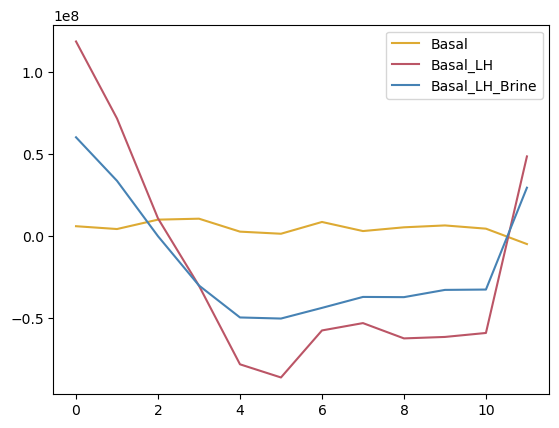

In [61]:
# plt.plot(melt_hint_shelf_ctrl_clim,label='ctrl',color='k')
plt.plot(melt_hint_shelf_noBG_clim-melt_hint_shelf_ctrl_clim
         ,label='Basal',color='#DDAA33')
plt.plot(melt_hint_shelf_BG_clim-melt_hint_shelf_ctrl_clim
         ,label='Basal_LH', color='#BB5566')
plt.plot(melt_hint_shelf_BGB_clim-melt_hint_shelf_ctrl_clim
         ,label='Basal_LH_Brine', color='steelblue')
plt.legend()

#### Final Figure!

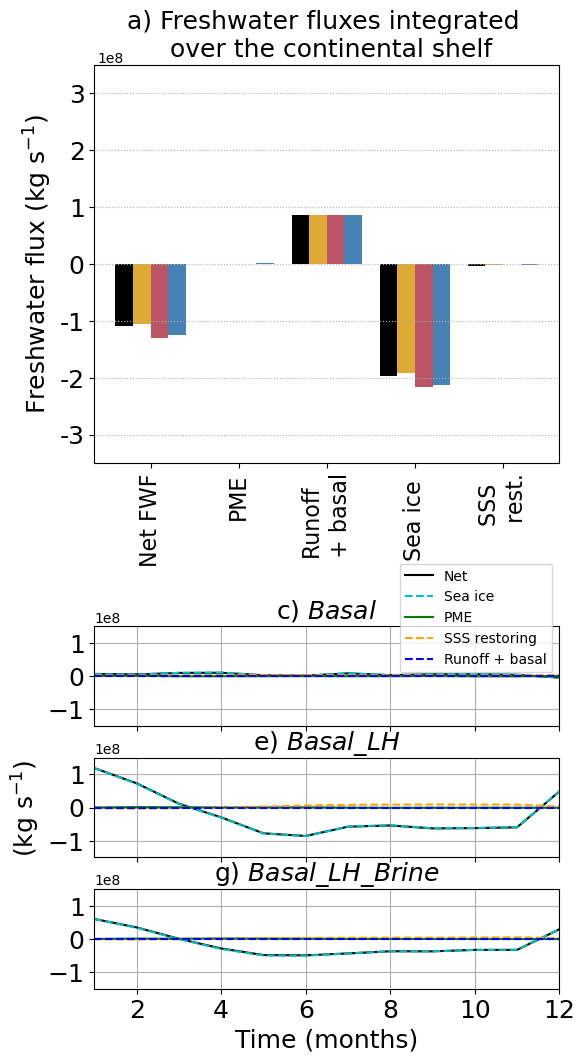

In [75]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(nrows=5,figsize = (6,12), gridspec_kw={'height_ratios': [1, 0.25, 0.25, 0.25, 0.25]})

# pme_river = pme_net + river +basal2d+icb2d
ax[0].bar(-.3, pme_river_annual_hint_shelf_ctrl, width=0.2, color='k', label='Control')
ax[0].bar(-.1, pme_river_annual_hint_shelf_noBG+ basal_annual_hint_shelf_noBG, width=0.2, color='#DDAA33', label='Basal')
ax[0].bar(0.1,  pme_river_annual_hint_shelf_BG+ basal_annual_hint_shelf_BG, width=0.2, color='#BB5566', label='BasalGade')
ax[0].bar(0.3, pme_river_annual_hint_shelf_BGB+(basal_annual_hint_shelf_BGB)+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue', label='BasalGadeBrine')

# plt.legend(fontsize=20)

# test with pme_net - melt
ax[0].bar(0.7, pme_net_annual_hint_shelf_ctrl - melt_annual_hint_shelf_ctrl, width=0.2, color='k')
ax[0].bar(.9, pme_net_annual_hint_shelf_noBG - melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
ax[0].bar(1.1,  pme_net_annual_hint_shelf_BG - melt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
ax[0].bar(1.3, pme_net_annual_hint_shelf_BGB - melt_annual_hint_shelf_BGB+ brine_annual_hint_shelf_BGB, width=0.2, color='steelblue')

ax[0].bar(1.7, river_annual_hint_shelf_ctrl, width=0.2, color='k')
ax[0].bar(1.9, river_annual_hint_shelf_noBG + basal_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
ax[0].bar(2.1,  river_annual_hint_shelf_BG + basal_annual_hint_shelf_BG, width=0.2, color='#BB5566')
ax[0].bar(2.3, river_annual_hint_shelf_BGB + basal_annual_hint_shelf_BGB, width=0.2, color='steelblue')

# pme_net includes melt!
ax[0].bar(2.7, melt_annual_hint_shelf_ctrl, width=0.2, color='k')
ax[0].bar(2.9, melt_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
ax[0].bar(3.1,  melt_annual_hint_shelf_BG, width=0.2, color='#BB5566')
ax[0].bar(3.3, melt_annual_hint_shelf_BGB, width=0.2, color='steelblue')

ax[0].bar(3.7, FW_restore_annual_hint_shelf_ctrl, width=0.2, color='k')
ax[0].bar(3.9, FW_restore_annual_hint_shelf_noBG, width=0.2, color='#DDAA33')
ax[0].bar(4.1,  FW_restore_annual_hint_shelf_BG, width=0.2, color='#BB5566')
ax[0].bar(4.3, FW_restore_annual_hint_shelf_BGB, width=0.2, color='steelblue')


ax[0].set_xticks(np.arange(0,5),('Net FWF','PME','Runoff \n + basal','Sea ice ',
                              'SSS \n rest.'),rotation=90,fontsize=16) 

ax[0].set_ylabel('Freshwater flux (kg s$^{-1}$)',fontsize=18)
ax[0].set_ylim(-3.5e8,3.5e8)
ax[0].yaxis.grid(True, linestyle=':')
ax[0].text(-0.6,3.53e8,'1e8')
ax[0].set_yticklabels([-4,-3,-2,-1,0,1,2,3],fontsize=18)


ax[0].set_title('a) Freshwater fluxes integrated \n over the continental shelf',fontsize=18)

# Leave the second subplot completely blank
ax[1].axis('off')  

ax[2].plot(np.arange(1,13),pme_river_hint_shelf_noBG_clim-pme_river_hint_shelf_ctrl_clim
         +basal_hint_shelf_noBG_clim
         ,label='Net',color='k')
ax[2].plot(np.arange(1,13),melt_hint_shelf_noBG_clim-melt_hint_shelf_ctrl_clim
         ,'--',label='Sea ice',color='c')
ax[2].plot(np.arange(1,13),pme_net_hint_shelf_noBG_clim-melt_hint_shelf_noBG_clim-
          (pme_net_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)
          ,'-',label='PME',color='g')
ax[2].plot(np.arange(1,13),FW_restore_hint_shelf_noBG_clim-FW_restore_hint_shelf_ctrl_clim
          ,'--',label='SSS restoring',color='orange')
ax[2].plot(np.arange(1,13),river_hint_shelf_noBG_clim+basal_hint_shelf_noBG_clim-
           (river_hint_shelf_ctrl_clim)
          ,'--',label='Runoff + basal',color='b')
# ax[2].plot(np.arange(1,13),
#            (melt_hint_shelf_noBG_clim-melt_hint_shelf_ctrl_clim)+
#            (pme_net_hint_shelf_noBG_clim-melt_hint_shelf_noBG_clim-
#             pme_net_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)+
#            (FW_restore_hint_shelf_noBG_clim-FW_restore_hint_shelf_ctrl_clim)+
#            river_hint_shelf_noBG_clim+basal_hint_shelf_noBG_clim-
#            (river_hint_shelf_ctrl_clim)
#           ,':',label='closure',color='magenta')
ax[2].legend(loc='upper right', bbox_to_anchor=(1, 1.7),fontsize=10)

ax[3].plot(np.arange(1,13),pme_river_hint_shelf_BG_clim-pme_river_hint_shelf_ctrl_clim
         +basal_hint_shelf_BG_clim
         ,label='Net', color='k')
ax[3].plot(np.arange(1,13),melt_hint_shelf_BG_clim-melt_hint_shelf_ctrl_clim
         ,'--',label='Sea ice', color='c')
ax[3].plot(np.arange(1,13),pme_net_hint_shelf_BG_clim-melt_hint_shelf_BG_clim-
          (pme_net_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)
          ,'-',label='PME', color='g')
ax[3].plot(np.arange(1,13),FW_restore_hint_shelf_BG_clim-FW_restore_hint_shelf_ctrl_clim
          ,'--',label='SSS restoring',color='orange')
ax[3].plot(np.arange(1,13),river_hint_shelf_BG_clim+basal_hint_shelf_BG_clim-
           (river_hint_shelf_ctrl_clim)
          ,'--',label='Runoff + basal',color='b')
# ax[3].plot(np.arange(1,13),
#            (melt_hint_shelf_BG_clim-melt_hint_shelf_ctrl_clim)+
#            (pme_net_hint_shelf_BG_clim-melt_hint_shelf_BG_clim-
#             pme_net_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)+
#            (FW_restore_hint_shelf_BG_clim-FW_restore_hint_shelf_ctrl_clim)+
#            river_hint_shelf_BG_clim+basal_hint_shelf_BG_clim-
#            (river_hint_shelf_ctrl_clim)
#           ,':',label='closure',color='magenta')

ax[4].plot(np.arange(1,13),pme_river_hint_shelf_BGB_clim-pme_river_hint_shelf_ctrl_clim
         +basal_hint_shelf_BGB_clim
         +brine_hint_shelf_BGB_clim
         ,label='Net', color='k')
ax[4].plot(np.arange(1,13),melt_hint_shelf_BGB_clim-melt_hint_shelf_ctrl_clim
         ,'--',label='Sea ice', color='c')
ax[4].plot(np.arange(1,13),pme_net_hint_shelf_BGB_clim-melt_hint_shelf_BGB_clim+brine_hint_shelf_BGB_clim-
          (pme_net_hint_shelf_ctrl_clim-melt_hint_shelf_ctrl_clim)
          ,'-',label='PME', color='g')
ax[4].plot(np.arange(1,13),FW_restore_hint_shelf_BGB_clim-FW_restore_hint_shelf_ctrl_clim
          ,'--',label='SSS restoring',color='orange')
ax[4].plot(np.arange(1,13),river_hint_shelf_BGB_clim+basal_hint_shelf_BGB_clim-
           (river_hint_shelf_ctrl_clim)
          ,'--',label='Runoff + basal',color='b')
# ax[4].plot(np.arange(1,13),
#            pme_net_hint_shelf_BGB_clim-
#             pme_net_hint_shelf_ctrl_clim+
#            (FW_restore_hint_shelf_BGB_clim-FW_restore_hint_shelf_ctrl_clim)+
#            river_hint_shelf_BGB_clim+basal_hint_shelf_BGB_clim-
#            (river_hint_shelf_ctrl_clim)
#           ,':',label='closure',color='magenta')

ax[4].set_xlabel('Time (months)',fontsize=18)
ax[2].set_xticklabels('')
ax[3].set_xticklabels('')

ax[2].tick_params(axis='both', labelsize=18)
ax[3].tick_params(axis='both', labelsize=18)
ax[4].tick_params(axis='both', labelsize=18)

ax[2].set_ylim(-1.5e8,+1.5e8)
ax[3].set_ylim(-1.5e8,+1.5e8)
ax[4].set_ylim(-1.5e8,+1.5e8)
ax[2].set_xlim(1,12)
ax[3].set_xlim(1,12)
ax[4].set_xlim(1,12)
ax[2].set_title('c) $Basal$',fontsize=18)
ax[3].set_title('e) $Basal{\_}LH$',fontsize=18)
ax[4].set_title('g) $Basal{\_}LH{\_}Brine$',fontsize=18)
ax[3].set_ylabel('(kg s$^{-1}$)',fontsize=18)

ax[2].grid('on')
ax[3].grid('on')
ax[4].grid('on')


### Save fig
plt.savefig(figdir+'SFWF_components_annual_hint_shelf_yr7-9_final.png',bbox_inches='tight',dpi=300)


In [78]:
print(figdir+'SFWF_components_annual_hint_shelf_yr7-9_final.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/SFWF_components_annual_hint_shelf_yr7-9_final.png


#### Some map plots below:

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(pme_river.xt_ocean, pme_river.yt_ocean, pme_river.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(pme_river_BG.xt_ocean, pme_river_BG.yt_ocean, pme_river_BG.mean('time')*area_t - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(pme_river_BGB.xt_ocean, pme_river_BGB.yt_ocean, (pme_river_BGB.mean('time')*area_t + brine_BGB.mean('time')) - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Net surface fw flux (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Net surface FW flux anomalies (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'pme_river_BG_BGB_anom_y'+str(year)+'.png')

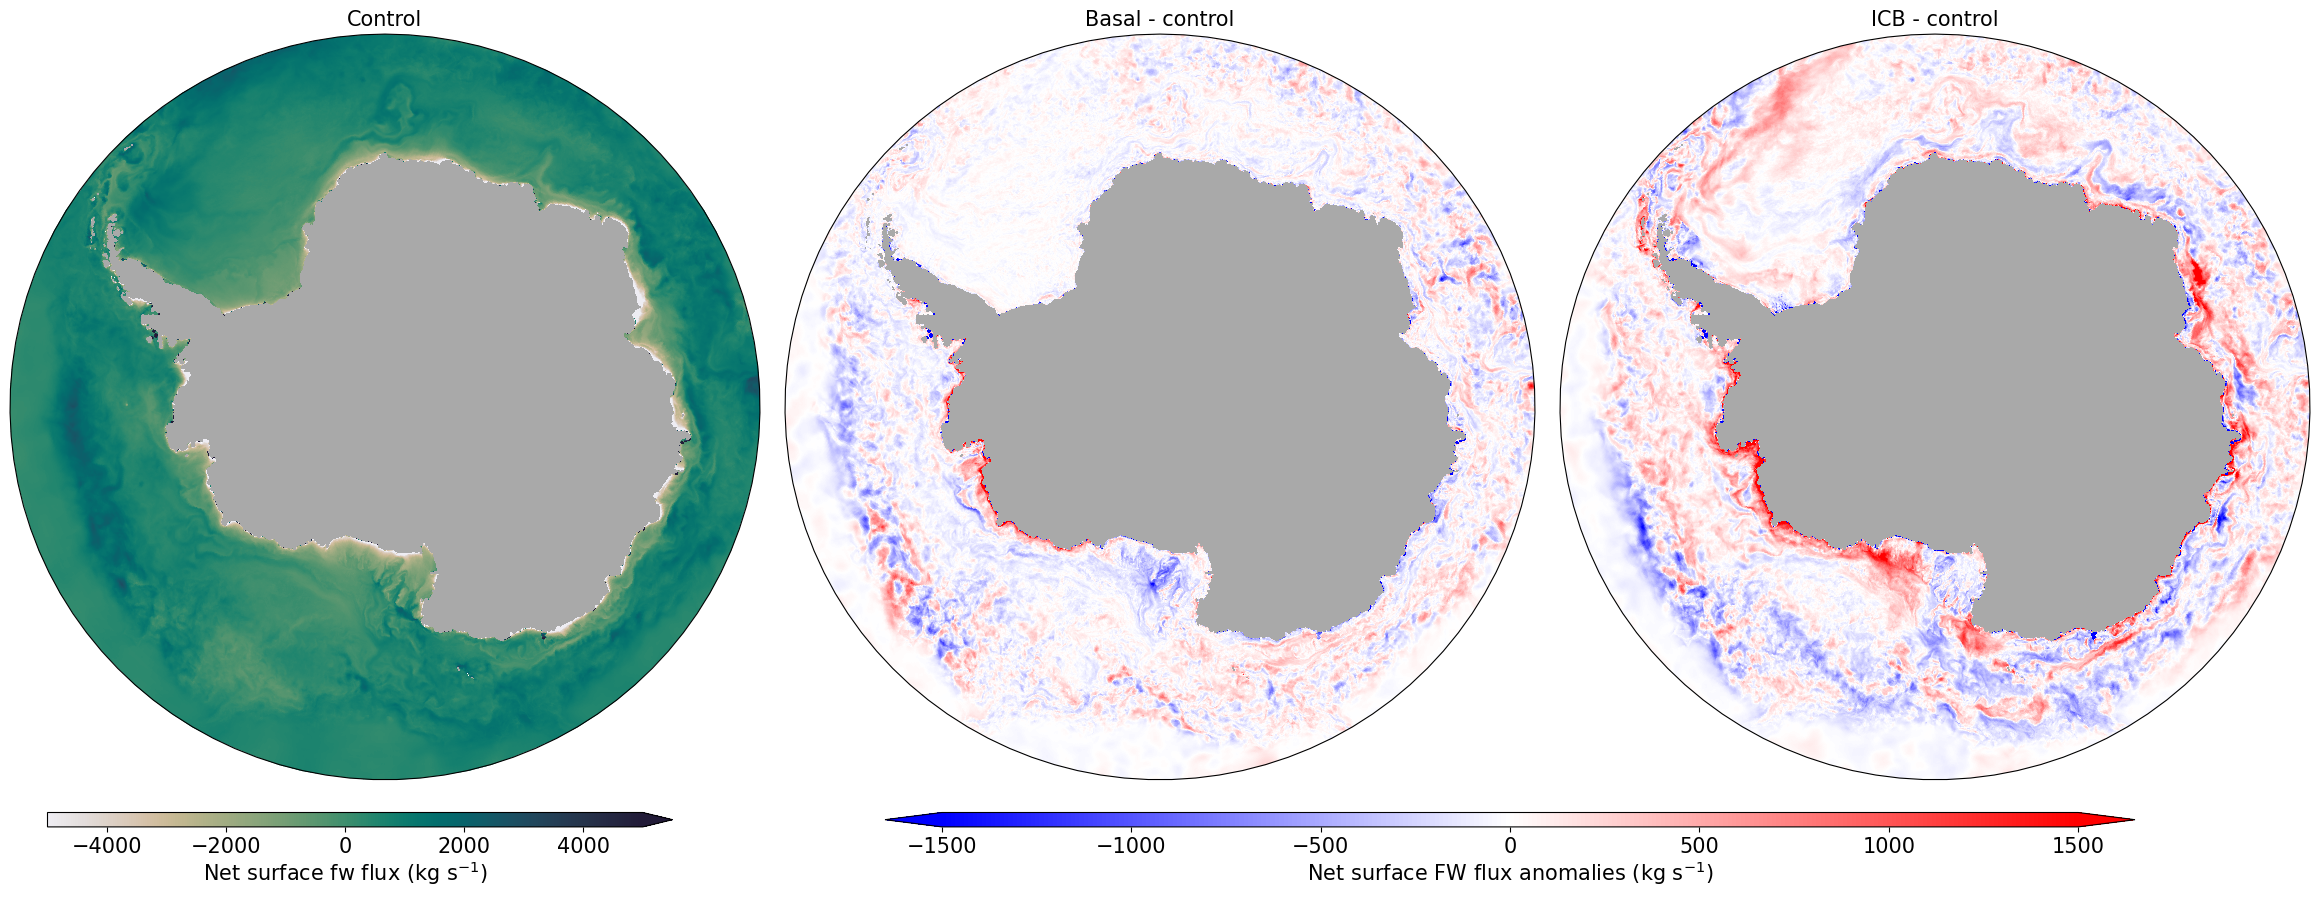

In [33]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(pme_river.xt_ocean, pme_river.yt_ocean, pme_river.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(pme_river_noBG.xt_ocean, pme_river_noBG.yt_ocean, pme_river_noBG.mean('time')*area_t - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(pme_river_ICB.xt_ocean, pme_river_ICB.yt_ocean, pme_river_ICB.mean('time')*area_t - pme_river.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Net surface fw flux (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Net surface FW flux anomalies (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'pme_river_noBG_ICB_anom_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(melt.xt_ocean, melt.yt_ocean, melt.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(melt_BG.xt_ocean, melt_BG.yt_ocean, melt_BG.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(melt_BGB.xt_ocean, melt_BGB.yt_ocean, melt_BGB.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea ice(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea ice (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'melt_anom_BG_BGB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-5000
rmax=5000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(melt.xt_ocean, melt.yt_ocean, melt.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1500
rmax=1500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(melt_noBG.xt_ocean, melt_noBG.yt_ocean, melt_noBG.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(melt_ICB.xt_ocean, melt_ICB.yt_ocean, melt_ICB.mean('time')*area_t - melt.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea ice(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea ice (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'melt_anom_noBG_ICB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_ice.xt_ocean, FW_ice.yt_ocean, FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_ice_BG.xt_ocean, FW_ice_BG.yt_ocean, FW_ice_BG.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_ice_BGB.xt_ocean, FW_ice_ICB.yt_ocean, FW_ice_ICB.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea-ice formation(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea-ice formation (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)


### Save fig
plt.savefig(figdir+'FW_ice_anom_BG_BGB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_ice.xt_ocean, FW_ice.yt_ocean, FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_ice_noBG.xt_ocean, FW_ice_noBG.yt_ocean, FW_ice_noBG.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_ice_ICB.xt_ocean, FW_ice_ICB.yt_ocean, FW_ice_ICB.mean('time')*area_t - FW_ice.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to sea-ice formation(kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to sea-ice formation (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)


### Save fig
plt.savefig(figdir+'FW_ice_anom_noBG_ICBB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_restore.xt_ocean, FW_restore.yt_ocean, FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_restore_BG.xt_ocean, FW_restore_BG.yt_ocean, FW_restore_BG.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGade - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sina(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_restore_BGB.xt_ocean, FW_restore_BGB.yt_ocean, FW_restore_BGB.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('BasalGadeBrine - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'FW_restore_anom_BG_BGB_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=-1000
rmax=1000

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(FW_restore.xt_ocean, FW_restore.yt_ocean, FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-500
rmax=500

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(FW_restore_noBG.xt_ocean, FW_restore_noBG.yt_ocean, FW_restore_noBG.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sina(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(FW_restore_ICB.xt_ocean, FW_restore_ICB.yt_ocean, FW_restore_ICB.mean('time')*area_t - FW_restore.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface fw flux due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface FW flux anomalies due to salt restoring (kg s$^{-1}$)',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'FW_restore_anom_noBG_ICB_y'+str(year)+'.png')